# Análisis del Pipeline de Machine Learning
**Dominio:** Detección de Fraude Financiero  
**Dataset:** Financial Fraud Detection (6.36M transacciones bancarias)  
**Módulo:** B — Pipeline ML  
**Modelos comparados:** Logistic Regression vs XGBoost

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src/ml'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay
import joblib
import json

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

PROCESSED = '../data/processed'
MODELS    = '../data/models'
REPORTS   = '../data/reports'

## 1. Exploración del Dataset

In [2]:
from preprocess import load_raw

# Load a small sample just for EDA visualization
df_raw = load_raw(sample_size=50_000)
print(df_raw.shape)
df_raw.head()

Loading data from: /Users/sergiomendez/Proyecto IA/Proyecto-AI/src/ml/../../data/raw/Synthetic_Financial_datasets_log.csv


Full dataset shape: (6362620, 11)


Sampled dataset shape: (50000, 11)
(50000, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
1005158,46,CASH_IN,82812.61,C2045765496,94057.99,176870.60,C1616574477,591195.97,508383.36,0,0
3610135,266,PAYMENT,3123.24,C1551703422,50036.00,46912.76,M616455084,0.00,0.00,0,0
369526,17,TRANSFER,305627.00,C1711670940,305627.00,0.00,C385061535,0.00,0.00,1,0
1340659,137,PAYMENT,51680.70,C151179513,243532.79,191852.09,M1730703519,0.00,0.00,0,0
5175152,359,CASH_IN,30096.99,C1061023977,7599823.47,7629920.46,C1246610976,106350.59,76253.60,0,0


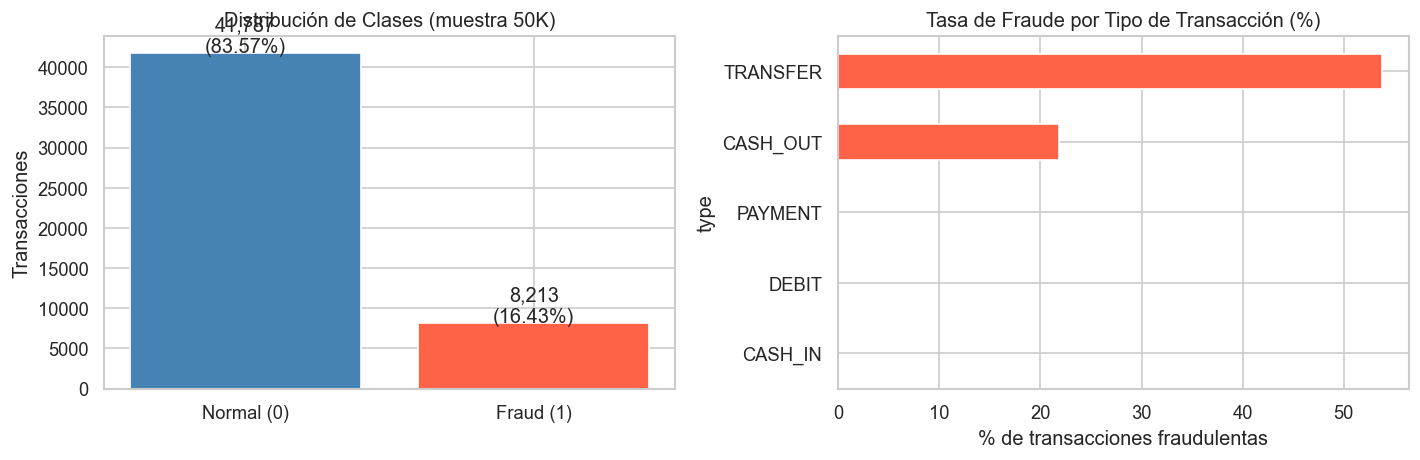

In [3]:
# Class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_raw['isFraud'].value_counts()
axes[0].bar(['Normal (0)', 'Fraud (1)'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Distribución de Clases (muestra 50K)')
axes[0].set_ylabel('Transacciones')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/counts.sum()*100:.2f}%)', ha='center')

# Fraud by transaction type
fraud_by_type = df_raw.groupby('type')['isFraud'].mean() * 100
fraud_by_type.sort_values().plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('Tasa de Fraude por Tipo de Transacción (%)')
axes[1].set_xlabel('% de transacciones fraudulentas')

plt.tight_layout()
plt.savefig(f'{REPORTS}/eda_class_distribution.png')
plt.show()

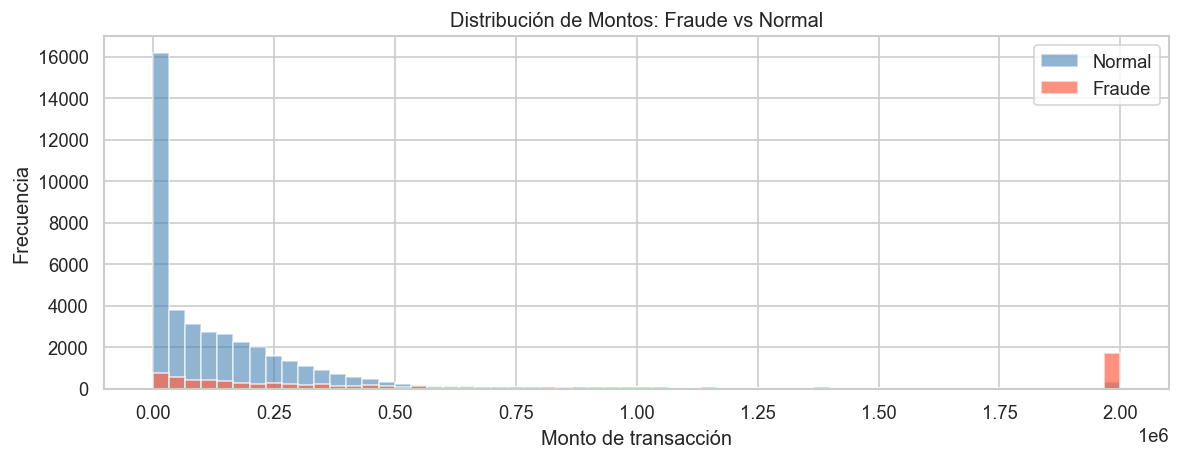

In [4]:
# Amount distribution: fraud vs normal
fig, ax = plt.subplots(figsize=(10, 4))
df_raw[df_raw['isFraud'] == 0]['amount'].clip(upper=2e6).hist(
    bins=60, alpha=0.6, label='Normal', ax=ax, color='steelblue'
)
df_raw[df_raw['isFraud'] == 1]['amount'].clip(upper=2e6).hist(
    bins=60, alpha=0.7, label='Fraude', ax=ax, color='tomato'
)
ax.set_xlabel('Monto de transacción')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Montos: Fraude vs Normal')
ax.legend()
plt.tight_layout()
plt.savefig(f'{REPORTS}/eda_amount_distribution.png')
plt.show()

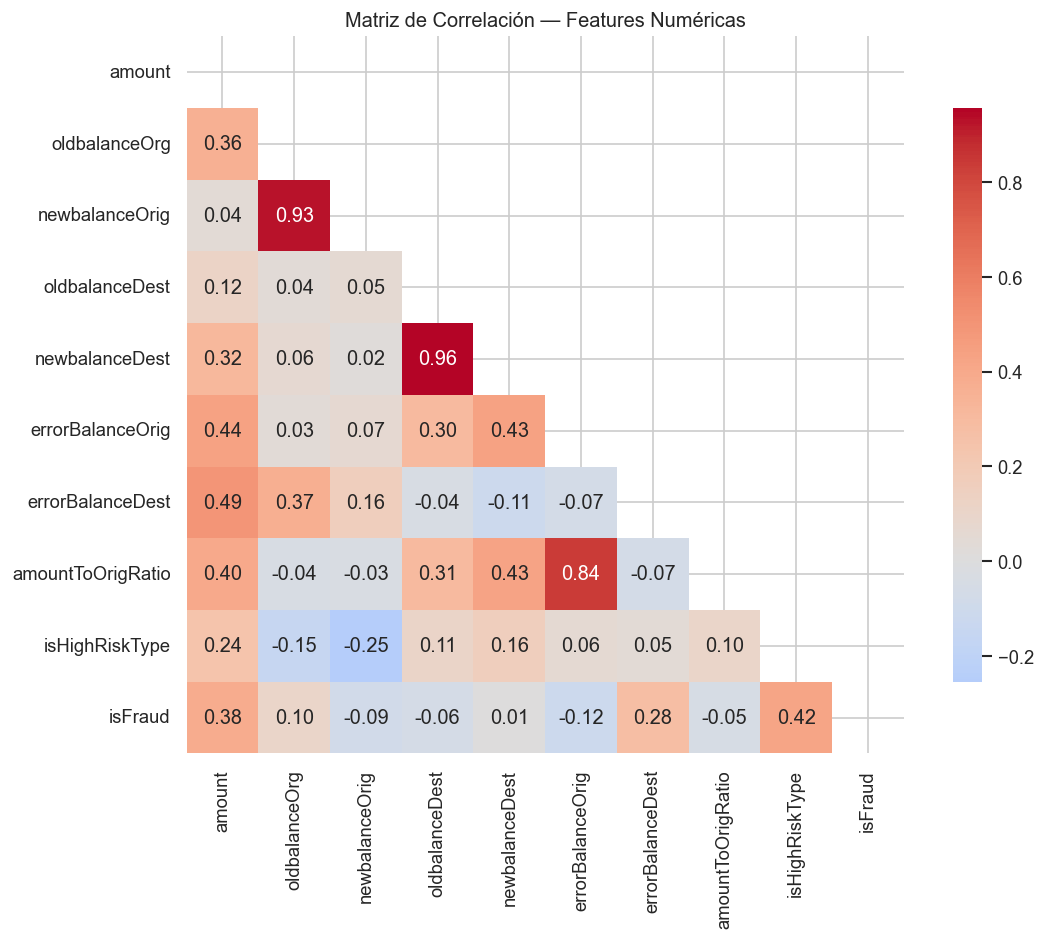

In [5]:
# Correlation heatmap (numeric features)
from preprocess import engineer_features, encode_type

df_feat = engineer_features(df_raw.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud']))
df_feat = encode_type(df_feat)

numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest',
                'errorBalanceOrig', 'errorBalanceDest',
                'amountToOrigRatio', 'isHighRiskType', 'isFraud']

fig, ax = plt.subplots(figsize=(10, 8))
corr = df_feat[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, cbar_kws={'shrink': .8})
ax.set_title('Matriz de Correlación — Features Numéricas')
plt.tight_layout()
plt.savefig(f'{REPORTS}/eda_correlation_heatmap.png')
plt.show()

## 2. Preprocesamiento

In [6]:
from preprocess import preprocess, load_processed

# Run preprocessing (uses 200K sample for manageable training time)
# Change sample_size=None to use the full 6.36M records
X_train, X_test, y_train, y_test, scaler = preprocess(
    sample_size=200_000, save=True
)

print(f'Train positives (fraud): {y_train.sum():,} ({y_train.mean()*100:.2f}%)')
print(f'Test  positives (fraud): {y_test.sum():,} ({y_test.mean()*100:.2f}%)')
print(f'\nFeatures ({X_train.shape[1]}):')
print(list(X_train.columns))

Loading data from: /Users/sergiomendez/Proyecto IA/Proyecto-AI/src/ml/../../data/raw/Synthetic_Financial_datasets_log.csv


Full dataset shape: (6362620, 11)


Sampled dataset shape: (200000, 11)

--- Class distribution (raw) ---
Fraud:  8,213  (4.1065%)
Normal: 191,787  (95.8935%)

Train size: 160,000 | Test size: 40,000
Features: 16

Processed data saved to /Users/sergiomendez/Proyecto IA/Proyecto-AI/src/ml/../../data/processed
Train positives (fraud): 6,570 (4.11%)
Test  positives (fraud): 1,643 (4.11%)

Features (16):
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest', 'origBalanceZero', 'amountToOrigRatio', 'isHighRiskType', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


## 3. Entrenamiento y Validación Cruzada

In [7]:
from train import run_training

# use_cached=True reuses processed data already saved
train_output = run_training(use_cached=True)

Loaded preprocessed data from cache.

Class imbalance ratio (neg/pos): 23.4x

--- Cross-validating: logistic_regression (5-fold StratifiedKFold) ---


  roc_auc        : 0.9938
  f1             : 0.7013
  precision      : 0.5493
  recall         : 0.9696
  cv_time_s      : 0.5000

--- Training final model: logistic_regression ---
  Done in 0.1s
  Saved to data/models/logistic_regression.pkl

--- Cross-validating: xgboost (5-fold StratifiedKFold) ---


  roc_auc        : 0.9997
  f1             : 0.9963
  precision      : 0.9959
  recall         : 0.9968
  cv_time_s      : 3.0000

--- Training final model: xgboost ---


  Done in 0.6s
  Saved to data/models/xgboost.pkl

=== Cross-Validation Summary ===
                      roc_auc        f1  precision    recall  cv_time_s
logistic_regression  0.993797  0.701255   0.549317  0.969559        0.5
xgboost              0.999705  0.996348   0.995897  0.996804        3.0


## 4. Evaluación en Test Set

In [8]:
from evaluate import evaluate_all

results = evaluate_all(threshold=0.5)


Model: logistic_regression
  accuracy          : 0.9667
  precision         : 0.5543
  recall            : 0.9726
  f1                : 0.7061
  roc_auc           : 0.9944
  avg_precision     : 0.9314

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98     38357
       Fraud       0.55      0.97      0.71      1643

    accuracy                           0.97     40000
   macro avg       0.78      0.97      0.84     40000
weighted avg       0.98      0.97      0.97     40000


Model: xgboost
  accuracy          : 0.9996
  precision         : 0.9945
  recall            : 0.9951
  f1                : 0.9948
  roc_auc           : 0.9999
  avg_precision     : 0.9986

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     38357
       Fraud       0.99      1.00      0.99      1643

    accuracy                           1.00     40000
   macro avg   


Plots saved to /Users/sergiomendez/Proyecto IA/Proyecto-AI/src/ml/../../data/reports/evaluation_plots.png


## 5. Curvas ROC — Comparación de Modelos

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'tomato', 'green']

for (name, data), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(data['y_true'], data['y_prob'])
    auc = data['metrics']['roc_auc']
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.4f})')

ax.plot([0,1],[0,1],'k--', lw=1, label='Baseline aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curvas ROC — Detección de Fraude Financiero')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{REPORTS}/roc_curves.png', dpi=150)
plt.show()

/var/folders/bx/jt5nb1291fz6bj4x_5npk78c0000gn/T/ipykernel_50255/1007010450.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 6. Matrices de Confusión

In [10]:
fig, axes = plt.subplots(1, len(results), figsize=(7 * len(results), 5))
if len(results) == 1:
    axes = [axes]

for ax, (name, data) in zip(axes, results.items()):
    cm = confusion_matrix(data['y_true'], data['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nF1={data["metrics"]["f1"]:.4f}')

plt.suptitle('Matrices de Confusión — Test Set', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(f'{REPORTS}/confusion_matrices.png', dpi=150)
plt.show()

/var/folders/bx/jt5nb1291fz6bj4x_5npk78c0000gn/T/ipykernel_50255/3144102673.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 7. Importancia de Features

In [11]:
feature_names = list(X_test.columns)

fig, axes = plt.subplots(1, len(results), figsize=(8 * len(results), 6))
if len(results) == 1:
    axes = [axes]

for ax, (name, data) in zip(axes, results.items()):
    model = data['model']
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
    else:
        continue
    top = 15
    idx = np.argsort(importances)[-top:]
    ax.barh([feature_names[i] for i in idx], importances[idx], color='steelblue')
    ax.set_title(f'Top {top} Features — {name}')
    ax.set_xlabel('Importancia')

plt.tight_layout()
plt.savefig(f'{REPORTS}/feature_importance.png', dpi=150)
plt.show()

/var/folders/bx/jt5nb1291fz6bj4x_5npk78c0000gn/T/ipykernel_50255/292626798.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 8. Análisis de Errores: Trade-off Precisión / Recall

In [12]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'tomato']

for (name, data), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(data['y_true'], data['y_prob'])
    ap = average_precision_score(data['y_true'], data['y_prob'])
    ax.plot(rec, prec, color=color, lw=2, label=f'{name} (AP={ap:.4f})')

ax.set_xlabel('Recall (Fraudes detectados)')
ax.set_ylabel('Precisión')
ax.set_title('Curva Precisión-Recall\n(más relevante que ROC con clases desbalanceadas)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{REPORTS}/precision_recall_curve.png', dpi=150)
plt.show()

print("""
ANÁLISIS DE ERRORES:
- En detección de fraude, los Falsos Negativos (fraude no detectado) tienen un costo
  económico directo para el cliente y el banco.
- Los Falsos Positivos (transacción normal bloqueada) generan fricción y pérdida de clientes.
- Por eso se prioriza el Recall sobre la Precisión, y el F1 como balance entre ambos.
- Con clases desbalanceadas (0.13% fraude), el ROC-AUC puede ser engañosamente alto;
  la curva Precisión-Recall es más informativa.
""")


ANÁLISIS DE ERRORES:
- En detección de fraude, los Falsos Negativos (fraude no detectado) tienen un costo
  económico directo para el cliente y el banco.
- Los Falsos Positivos (transacción normal bloqueada) generan fricción y pérdida de clientes.
- Por eso se prioriza el Recall sobre la Precisión, y el F1 como balance entre ambos.
- Con clases desbalanceadas (0.13% fraude), el ROC-AUC puede ser engañosamente alto;
  la curva Precisión-Recall es más informativa.



/var/folders/bx/jt5nb1291fz6bj4x_5npk78c0000gn/T/ipykernel_50255/3043822389.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 9. Tabla Resumen Final

In [13]:
comparison = pd.DataFrame({name: data['metrics'] for name, data in results.items()}).T
comparison.index.name = 'Modelo'
comparison.style.highlight_max(axis=0, color='lightgreen') \
                .format('{:.4f}') \
                .set_caption('Comparación de Modelos — Test Set')

,accuracy,precision,recall,f1,roc_auc,avg_precision
Modelo,,,,,,
logistic_regression,0.9667,0.5543,0.9726,0.7061,0.9944,0.9314
xgboost,0.9996,0.9945,0.9951,0.9948,0.9999,0.9986
